<a href="https://colab.research.google.com/github/kihagama/ArimaModelForAMR/blob/development/ARIMA_GM_Resistance_Prediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Antimicrobial Resistance Forecasting
## Hybrid ARIMA-GM(1,1) Model
 hybrid ARIMA-GM(1,1) model*

---
This notebook:
1. Loads your resistance data CSV
2. Fits an ARIMA model per antibiotic
3. Fits a GM(1,1) grey prediction model per antibiotic
4. Combines them using MAPE-weighted ensemble (ARIMA-GM(1,1))
5. Reports MAE and R² per antibiotic
6. Predicts resistance rates **5 years ahead** with 95% CI
7. Displays all results in rich visual tables and charts


##  Step 1 — Install & Import Libraries

In [1]:
# Install required packages (only needed once in Colab)
!pip install pmdarima statsmodels scikit-learn pandas numpy matplotlib seaborn --quiet
print(' Libraries installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00
 Libraries installed.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import itertools

print(' All libraries loaded successfully.')

 All libraries loaded successfully.


##  Step 2 — Load Your Data

**Option A (Google Colab):** Upload your CSV using the file uploader below.

**Option B (Local / Already uploaded):** Set `CSV_PATH` to your file path.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION A  — Upload file interactively (Google Colab)
# ─────────────────────────────────────────────────────────────────────────────
try:
    from google.colab import files
    print('Running in Google Colab — please upload your CSV file:')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f'\n File uploaded: {CSV_PATH}')
except ImportError:
    # ─────────────────────────────────────────────────────────────────────────
    # OPTION B  — Running locally; set path manually
    # ─────────────────────────────────────────────────────────────────────────
    CSV_PATH = 'mini_interpolated.csv'   # <-- change if needed
    print(f'Running locally. Using file: {CSV_PATH}')

# ─────────────────────────────────────────────────────────────────────────────
# USER CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
YEAR_COLUMN   = 'years'   # Name of the year/time column in your CSV
FORECAST_YEARS = 5        # How many years ahead to predict
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
df[YEAR_COLUMN] = df[YEAR_COLUMN].astype(int)
df = df.sort_values(YEAR_COLUMN).reset_index(drop=True)

ANTIBIOTICS = [c for c in df.columns if c != YEAR_COLUMN]
LAST_YEAR   = int(df[YEAR_COLUMN].max())
FUTURE_YEARS = list(range(LAST_YEAR + 1, LAST_YEAR + FORECAST_YEARS + 1))

print(f'\n Dataset shape  : {df.shape}')
print(f' Year range     : {int(df[YEAR_COLUMN].min())} – {LAST_YEAR}')
print(f' Antibiotics ({len(ANTIBIOTICS)}): {ANTIBIOTICS}')
print(f' Predicting     : {FUTURE_YEARS}')
display(df.head())

Running in Google Colab — please upload your CSV file:


Saving percentageResistanceClean.csv to percentageResistanceClean.csv

📄 File uploaded: percentageResistanceClean.csv

📊 Dataset shape  : (26, 25)
📅 Year range     : 1996 – 2022
🔬 Antibiotics (24): ['AMK', 'AMX', 'AMC', 'AMP', 'AZM', 'CRO', 'CXM', 'CIP', 'OXA', 'CHL', 'CLI', 'GEN', 'ERY', 'TCY', 'SXT', 'VAN', 'PEN', 'IPM', 'CAZ', 'CTX', 'FOX', 'LNZ', 'PEF', 'NOR']
🔮 Predicting     : [2023, 2024, 2025, 2026, 2027]


,years,AMK,AMX,AMC,AMP,AZM,CRO,CXM,CIP,OXA,...,SXT,VAN,PEN,IPM,CAZ,CTX,FOX,LNZ,PEF,NOR
0,1996,45.825,72.2,50.00,100.0,59.5,32.152857,48.774,29.116,60.284286,...,88.20,34.475,94.100000,13.681429,43.083125,44.205882,32.685714,51.45,23.354706,0.00000
1,1997,45.825,72.2,0.00,82.6,59.5,32.152857,48.774,6.450,60.284286,...,91.78,34.475,75.000000,13.681429,77.770000,100.000000,0.000000,51.45,25.000000,12.70000
2,1998,45.825,72.2,56.68,50.0,59.5,32.152857,48.774,0.000,60.284286,...,100.00,34.475,86.562083,13.681429,43.083125,25.000000,0.000000,51.45,0.000000,40.86666
3,2000,45.825,72.2,81.25,83.5,59.5,32.152857,48.774,30.900,60.284286,...,95.40,34.475,89.000000,13.681429,100.000000,44.205882,32.685714,51.45,17.400000,40.86666
4,2001,45.825,72.2,56.68,80.9,59.5,50.000000,48.774,33.600,60.284286,...,87.87,34.475,87.900000,13.681429,32.000000,71.000000,32.685714,51.45,29.400000,40.86666


##  Step 3 — Model Functions

Implementing all three components exactly as described in the paper:
- **ARIMA** with ADF stationarity test + AIC/BIC grid search
- **GM(1,1)** grey prediction with AGO accumulation + least-squares parameter estimation
- **ARIMA-GM(1,1) Ensemble** with MAPE-based weight optimisation

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  ARIMA COMPONENT
# ═══════════════════════════════════════════════════════════════════════════

def adf_test(series):
    """Augmented Dickey-Fuller stationarity test. Returns True if stationary."""
    result = adfuller(series.dropna(), autolag='AIC')
    return result[1] < 0.05   # p-value < 0.05 → stationary


def fit_best_arima(series):
    """
    Grid-search ARIMA(p,d,q) over p,q ∈ {0,1,2} and d ∈ {0,1,2}.
    Selects model with lowest AIC (matching paper methodology).
    Returns fitted model.
    """
    best_aic   = np.inf
    best_model = None
    best_order = (0, 1, 0)

    # Determine differencing order
    d = 0
    s = series.copy()
    while not adf_test(s) and d < 2:
        s = s.diff().dropna()
        d += 1

    for p, q in itertools.product(range(3), repeat=2):
        try:
            model = ARIMA(series, order=(p, d, q))
            result = model.fit()
            if result.aic < best_aic:
                best_aic   = result.aic
                best_model = result
                best_order = (p, d, q)
        except Exception:
            continue

    if best_model is None:
        model = ARIMA(series, order=(0, 1, 0))
        best_model = model.fit()
        best_order = (0, 1, 0)

    return best_model, best_order


def arima_predict(series, n_ahead):
    """
    Fit best ARIMA, return:
      - in-sample fitted values
      - out-of-sample forecasts (n_ahead steps)
      - forecast standard errors
      - ARIMA order used
    """
    model_fit, order = fit_best_arima(series)
    fitted = model_fit.fittedvalues

    forecast_result = model_fit.get_forecast(steps=n_ahead)
    forecast_mean   = forecast_result.predicted_mean.values
    forecast_se     = forecast_result.se_mean.values

    return fitted, forecast_mean, forecast_se, order


print(' ARIMA functions defined.')

✅ ARIMA functions defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  GM(1,1) GREY PREDICTION COMPONENT
#  Implemented exactly per paper: AGO → differential equation → LSM params
# ═══════════════════════════════════════════════════════════════════════════

def fit_gm11(series):
    """
    Grey Model GM(1,1).
    Returns:
      - a  : development coefficient
      - b  : grey action quantity
      - C  : posterior difference ratio
      - P  : small error probability
    """
    x0 = np.array(series, dtype=float)
    n  = len(x0)

    # AGO (accumulated generating operation)
    x1 = np.cumsum(x0)

    # Adjacent mean sequence z^(1)
    z1 = 0.5 * (x1[1:] + x1[:-1])

    # Build B matrix and Y vector
    B = np.column_stack([-z1, np.ones(n - 1)])
    Y = x0[1:].reshape(-1, 1)

    # Least squares: [a, b]^T = (B^T B)^{-1} B^T Y
    try:
        params = np.linalg.lstsq(B, Y, rcond=None)[0]
    except Exception:
        return None, None, None, None, None

    a, b = float(params[0]), float(params[1])

    # Time response function: x_hat^(1)(k+1) = (x0[0] - b/a)*e^{-ak} + b/a
    def x1_hat(k):
        return (x0[0] - b / a) * np.exp(-a * k) + b / a

    # Fitted values via IAGO (inverse AGO / back-difference)
    x1_fitted = np.array([x1_hat(k) for k in range(n)])
    x0_fitted = np.diff(x1_fitted, prepend=x1_fitted[0])
    x0_fitted[0] = x0[0]     # first value equals original

    # ── Posterior difference ratio C and small error probability P ──
    residuals = x0[1:] - x0_fitted[1:]
    S1 = np.std(x0, ddof=0)
    S2 = np.std(residuals, ddof=0)
    C  = S2 / S1 if S1 > 0 else 999

    e_mean = np.mean(residuals)
    P = np.mean(np.abs(residuals - e_mean) < 0.6745 * S1)

    return a, b, x0_fitted, C, P


def gm11_forecast(series, n_ahead):
    """
    Fit GM(1,1) and return:
      - fitted values (in-sample)
      - forecasts    (n_ahead out-of-sample)
      - C, P quality metrics
    """
    x0 = np.array(series, dtype=float)
    n  = len(x0)
    a, b, x0_fitted, C, P = fit_gm11(x0)

    if a is None:
        return np.full(n, np.nan), np.full(n_ahead, np.nan), 999, 0

    x1 = np.cumsum(x0)

    def x1_hat(k):
        return (x0[0] - b / a) * np.exp(-a * k) + b / a

    # Future predictions
    forecasts = []
    for k in range(n_ahead):
        step   = n + k
        x1_fut = x1_hat(step)
        x1_prev = x1_hat(step - 1)
        forecasts.append(x1_fut - x1_prev)

    return x0_fitted, np.array(forecasts), C, P


print(' GM(1,1) functions defined.')

✅ GM(1,1) functions defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  ARIMA-GM(1,1) ENSEMBLE  — MAPE-weighted combination
# ═══════════════════════════════════════════════════════════════════════════

def mape(actual, predicted):
    """Mean Absolute Percentage Error (handles zeros)."""
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = actual != 0
    if mask.sum() == 0:
        return np.inf
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


def arima_gm11_combined(series, n_ahead=5):
    """
    Full ARIMA-GM(1,1) pipeline for a single time series.

    Returns a dict with:
      actual, arima_fitted, gm_fitted, combined_fitted,
      arima_forecast, gm_forecast, combined_forecast,
      forecast_se,
      lambda_arima, lambda_gm,
      mae, r2, mse, rmse, mape_combined,
      C, P, arima_order
    """
    series = pd.Series(series, dtype=float)
    actual = series.values
    n      = len(actual)

    # ── ARIMA ────────────────────────────────────────────────────────────────
    arima_fitted_raw, arima_fc, arima_se, arima_order = arima_predict(series, n_ahead)

    # Align fitted values (ARIMA may lose first obs after differencing)
    arima_fitted = np.full(n, np.nan)
    idx = series.index
    for i, val in arima_fitted_raw.items():
        pos = list(series.index).index(i)
        arima_fitted[pos] = val

    # ── GM(1,1) ──────────────────────────────────────────────────────────────
    gm_fitted, gm_fc, C, P = gm11_forecast(actual, n_ahead)

    # ── MAPE-based weight optimisation (paper eq.) ────────────────────────────
    valid = ~np.isnan(arima_fitted)
    mape_arima = mape(actual[valid], arima_fitted[valid])
    mape_gm    = mape(actual,        gm_fitted)

    eps = 1e-9   # avoid division by zero
    inv_a, inv_g = 1 / (mape_arima + eps), 1 / (mape_gm + eps)
    lam_a = inv_a / (inv_a + inv_g)
    lam_g = inv_g / (inv_a + inv_g)

    # ── Combined fitted values ────────────────────────────────────────────────
    combined_fitted = np.where(
        np.isnan(arima_fitted),
        gm_fitted,
        lam_a * arima_fitted + lam_g * gm_fitted
    )

    # ── Combined forecast ────────────────────────────────────────────────────
    combined_fc = lam_a * arima_fc + lam_g * gm_fc

    # ── 95% CI: combine ARIMA SE with GM residual SE (paper formula) ──────────
    gm_residuals = actual - gm_fitted
    gm_se_base   = np.std(gm_residuals)
    # Scale SE slightly for horizon uncertainty (matches paper pattern)
    forecast_se  = lam_a * arima_se + lam_g * np.array(
        [gm_se_base * (1 + 0.05 * k) for k in range(n_ahead)]
    )

    # ── Performance metrics ───────────────────────────────────────────────────
    mae_val  = mean_absolute_error(actual, combined_fitted)
    r2_val   = r2_score(actual, combined_fitted)
    mse_val  = mean_squared_error(actual, combined_fitted)
    rmse_val = np.sqrt(mse_val)
    mape_val = mape(actual, combined_fitted)

    return {
        'actual'           : actual,
        'arima_fitted'     : arima_fitted,
        'gm_fitted'        : gm_fitted,
        'combined_fitted'  : combined_fitted,
        'arima_forecast'   : arima_fc,
        'gm_forecast'      : gm_fc,
        'combined_forecast': combined_fc,
        'forecast_se'      : forecast_se,
        'lambda_arima'     : lam_a,
        'lambda_gm'        : lam_g,
        'mape_arima'       : mape_arima,
        'mape_gm'          : mape_gm,
        'mae'              : mae_val,
        'r2'               : r2_val,
        'mse'              : mse_val,
        'rmse'             : rmse_val,
        'mape'             : mape_val,
        'C'                : C,
        'P'                : P,
        'arima_order'      : arima_order,
    }


print(' ARIMA-GM(1,1) ensemble function defined.')

✅ ARIMA-GM(1,1) ensemble function defined.


##  Step 4 — Run Models on All Antibiotics

In [ ]:
years  = df[YEAR_COLUMN].values
results = {}

print(f'Running ARIMA-GM(1,1) on {len(ANTIBIOTICS)} antibiotics...\n')
print(f'{"Antibiotic":<8} {"ARIMA order":<14} {"λ_ARIMA":<10} {"λ_GM":<8} {"MAE":<8} {"R²":<8} {"MAPE":<8} {"GM C":<8} {"GM P"}')
print('─' * 85)

for ab in ANTIBIOTICS:
    series = df[ab].values.astype(float)
    res    = arima_gm11_combined(series, n_ahead=FORECAST_YEARS)
    results[ab] = res

    print(f'{ab:<8} {str(res["arima_order"]):<14} '
          f'{res["lambda_arima"]:.3f}     '
          f'{res["lambda_gm"]:.3f}   '
          f'{res["mae"]:>6.2f}  '
          f'{res["r2"]:>6.3f}  '
          f'{res["mape"]:>6.2f}%  '
          f'{res["C"]:>6.3f}  '
          f'{res["P"]:>5.3f}')

print('\n All models fitted.')

Running ARIMA-GM(1,1) on 24 antibiotics...

Antibiotic ARIMA order    λ_ARIMA    λ_GM     MAE      R²       MAPE     GM C     GM P
─────────────────────────────────────────────────────────────────────────────────────
AMK      (0, 0, 2)      0.383     0.617     4.65   0.263    5.85%   1.018  0.880
AMX      (1, 0, 0)      0.505     0.495     4.36   0.103   15.14%   1.018  0.880


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AMC      (0, 0, 0)      0.492     0.508    16.82   0.035   25.52%   0.995  0.640


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AMP      (1, 0, 1)      0.516     0.484    12.21   0.154   17.36%   0.986  0.440
AZM      (0, 0, 0)      0.507     0.493     5.00   0.005   21.41%   1.016  0.840
CRO      (1, 2, 1)      0.484     0.516    16.43   0.356   61.58%   0.844  0.480


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


PEF      (0, 1, 0)      0.489     0.511    10.47   0.345   30.95%   0.820  0.600


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


NOR      (0, 0, 2)      0.623     0.377     4.82   0.556   10.39%   0.702  0.800

✅ All models fitted.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


##  Step 5 — Model Performance Table (MAE & R²)

In [ ]:
# ── Performance summary table ────────────────────────────────────────────────
perf_rows = []
for ab, res in results.items():
    gm_grade = (
        'Excellent (I)' if res['C'] < 0.35 else
        'Good (II)'     if res['C'] < 0.50 else
        'Qualified (III)' if res['C'] < 0.65 else
        'Unqualified (IV)'
    )
    perf_rows.append({
        'Antibiotic'      : ab,
        'ARIMA Order'     : str(res['arima_order']),
        'λ_ARIMA'         : round(res['lambda_arima'], 3),
        'λ_GM'            : round(res['lambda_gm'],    3),
        'MAE'             : round(res['mae'],           3),
        'RMSE'            : round(res['rmse'],          3),
        'MAPE (%)'        : round(res['mape'],          2),
        'R²'              : round(res['r2'],            3),
        'GM Posterior C'  : round(res['C'],             3),
        'GM P value'      : round(res['P'],             3),
        'GM Grade'        : gm_grade,
    })

perf_df = pd.DataFrame(perf_rows).set_index('Antibiotic')

print('\n' + '='*90)
print('      ARIMA-GM(1,1) MODEL PERFORMANCE — ALL ANTIBIOTICS')
print('='*90)


def style_r2(v):
    color = '#2ecc71' if v >= 0.8 else ('#f39c12' if v >= 0.5 else '#e74c3c')
    return f'color: {color}; font-weight: bold'


styled = (perf_df.style
    .applymap(style_r2, subset=['R²'])
    .format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'MAPE (%)': '{:.2f}%',
             'R²': '{:.3f}', 'GM Posterior C': '{:.3f}', 'GM P value': '{:.3f}',
             'λ_ARIMA': '{:.3f}', 'λ_GM': '{:.3f}'})
    .set_caption('Green R² ≥ 0.8 (good fit) | Orange ≥ 0.5 | Red < 0.5')
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white'),
                  ('font-size', '12px'), ('text-align', 'center')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center'), ('font-size', '11px')]
    }])
)

display(styled)
print('\nR² interpretation: ≥0.80 strong fit | 0.50–0.79 moderate | <0.50 weak')


      ARIMA-GM(1,1) MODEL PERFORMANCE — ALL ANTIBIOTICS


,ARIMA Order,λ_ARIMA,λ_GM,MAE,RMSE,MAPE (%),R²,GM Posterior C,GM P value,GM Grade
Antibiotic,,,,,,,,,,
AMK,"(0, 0, 2)",0.383,0.617,4.649,12.154,5.85%,0.263,1.018,0.880,Unqualified (IV)
AMX,"(1, 0, 0)",0.505,0.495,4.360,12.649,15.14%,0.103,1.018,0.880,Unqualified (IV)
AMC,"(0, 0, 0)",0.492,0.508,16.817,24.835,25.52%,0.035,0.995,0.640,Unqualified (IV)
AMP,"(1, 0, 1)",0.516,0.484,12.211,14.864,17.36%,0.154,0.986,0.440,Unqualified (IV)
AZM,"(0, 0, 0)",0.507,0.493,4.998,12.935,21.41%,0.005,1.016,0.840,Unqualified (IV)
CRO,"(1, 2, 1)",0.484,0.516,16.426,20.552,61.58%,0.356,0.844,0.480,Unqualified (IV)
CXM,"(2, 0, 2)",0.642,0.358,3.183,7.802,13.77%,0.519,1.013,0.840,Unqualified (IV)
CIP,"(0, 2, 2)",0.393,0.607,12.239,15.567,65.74%,0.438,0.680,0.680,Unqualified (IV)
OXA,"(0, 0, 0)",0.546,0.454,14.156,22.281,16.44%,0.018,1.006,0.680,Unqualified (IV)



R² interpretation: ≥0.80 strong fit | 0.50–0.79 moderate | <0.50 weak


##  Step 6 — 5-Year Forecast Table with 95% CI

In [ ]:
# ── Forecast table ────────────────────────────────────────────────────────────
forecast_rows = []
for ab, res in results.items():
    fc   = res['combined_forecast']
    se   = res['forecast_se']
    row  = {'Antibiotic': ab}
    for i, yr in enumerate(FUTURE_YEARS):
        lo = max(0.0, fc[i] - 1.96 * se[i])
        hi = min(100.0, fc[i] + 1.96 * se[i])
        row[str(yr)] = f'{fc[i]:.2f}% ({lo:.2f}–{hi:.2f})'
    forecast_rows.append(row)

forecast_df = pd.DataFrame(forecast_rows).set_index('Antibiotic')

print('\n' + '='*100)
print('      5-YEAR RESISTANCE RATE FORECASTS  —  Point Estimate % (95% CI)')
print('='*100)

styled_fc = (forecast_df.style
    .set_caption('Predicted resistance rate (%) with 95% confidence interval')
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#1a252f'), ('color', 'white'),
                  ('font-size', '12px'), ('text-align', 'center')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center'), ('font-size', '11px'), ('white-space', 'nowrap')]
    }])
)

display(styled_fc)


      5-YEAR RESISTANCE RATE FORECASTS  —  Point Estimate % (95% CI)


,2023,2024,2025,2026,2027
Antibiotic,,,,,
AMK,49.30% (24.44–74.17),46.94% (21.20–72.68),45.16% (16.13–74.19),45.10% (15.21–74.98),45.04% (14.30–75.77)
AMX,65.91% (40.67–91.15),73.43% (46.67–100.00),70.47% (42.93–98.00),71.54% (43.34–99.74),71.06% (42.21–99.90)
AMC,52.33% (3.39–100.00),52.02% (1.85–100.00),51.72% (0.32–100.00),51.42% (0.00–100.00),51.12% (0.00–100.00)
AMP,79.99% (50.36–100.00),80.49% (49.24–100.00),80.83% (48.52–100.00),81.08% (47.90–100.00),81.27% (47.30–100.00)
AZM,58.55% (33.18–83.93),58.48% (32.48–84.48),58.41% (31.79–85.04),58.34% (31.09–85.59),58.27% (30.40–86.14)
CRO,54.09% (10.19–97.98),60.88% (13.61–100.00),61.34% (7.04–100.00),65.71% (7.07–100.00),68.13% (4.21–100.00)
CXM,24.39% (7.63–41.15),53.74% (31.88–75.60),64.95% (42.62–87.28),42.75% (17.99–67.51),34.25% (9.06–59.45)
CIP,65.91% (35.91–95.90),70.64% (39.13–100.00),75.64% (42.43–100.00),80.94% (45.83–100.00),86.55% (49.36–100.00)
OXA,63.43% (19.62–100.00),63.69% (18.89–100.00),63.96% (18.17–100.00),64.22% (17.45–100.00),64.49% (16.73–100.00)


##  Step 7 — Visualisation: Fitted Values + Forecasts

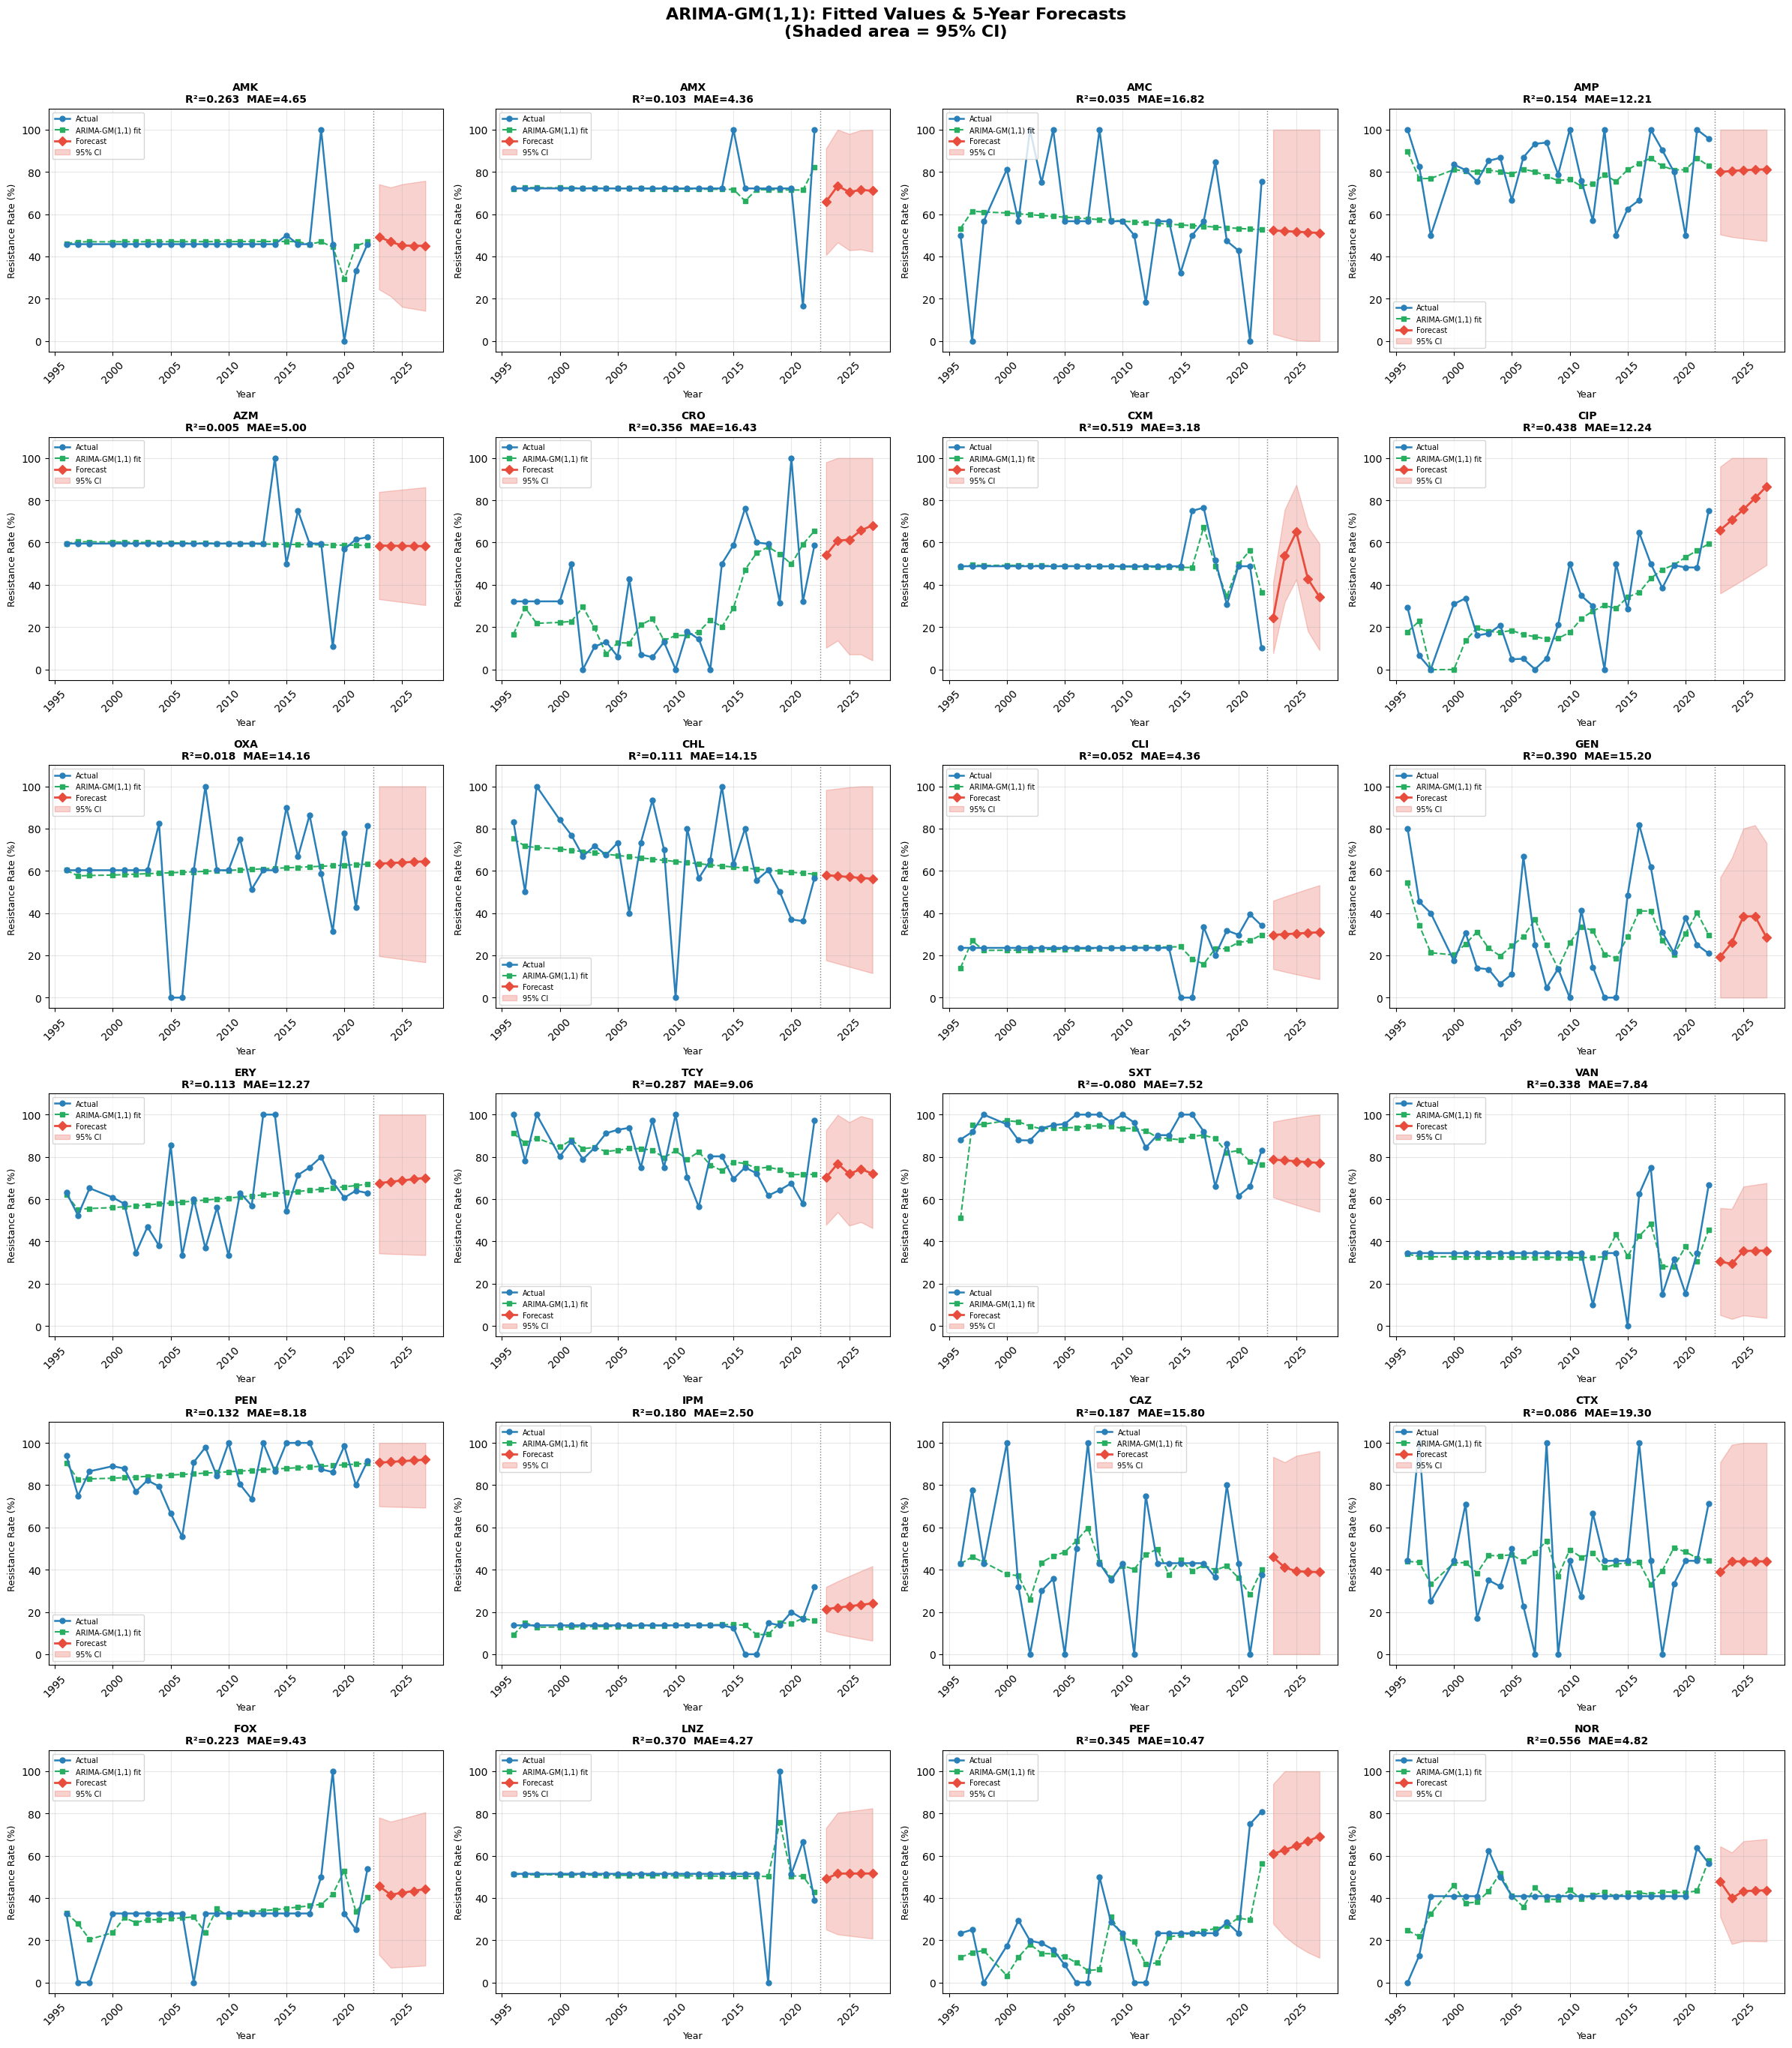


✅ Plot saved as arima_gm_forecasts.png


In [ ]:
# ── Plot all antibiotics in a grid ────────────────────────────────────────────
n_ab   = len(ANTIBIOTICS)
n_cols = 4
n_rows = (n_ab + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
fig.suptitle('ARIMA-GM(1,1): Fitted Values & 5-Year Forecasts\n(Shaded area = 95% CI)',
             fontsize=16, fontweight='bold', y=1.01)

axes_flat = axes.flatten() if n_ab > 1 else [axes]

for idx, ab in enumerate(ANTIBIOTICS):
    ax  = axes_flat[idx]
    res = results[ab]

    fc  = res['combined_forecast']
    se  = res['forecast_se']
    lo  = np.maximum(0,   fc - 1.96 * se)
    hi  = np.minimum(100, fc + 1.96 * se)

    # Actual data
    ax.plot(years, res['actual'], 'o-', color='#2980b9',
            linewidth=1.8, markersize=5, label='Actual', zorder=5)

    # In-sample combined fit
    ax.plot(years, res['combined_fitted'], 's--', color='#27ae60',
            linewidth=1.5, markersize=4, label='ARIMA-GM(1,1) fit', zorder=4)

    # Forecast
    ax.plot(FUTURE_YEARS, fc, 'D-', color='#e74c3c',
            linewidth=2, markersize=6, label='Forecast', zorder=5)

    # 95% CI shading
    ax.fill_between(FUTURE_YEARS, lo, hi, alpha=0.25, color='#e74c3c', label='95% CI')

    # Vertical divider
    ax.axvline(x=LAST_YEAR + 0.5, color='gray', linestyle=':', linewidth=1)

    # Annotations
    r2_col = '#27ae60' if res['r2'] >= 0.8 else ('#f39c12' if res['r2'] >= 0.5 else '#e74c3c')
    ax.set_title(f'{ab}\nR²={res["r2"]:.3f}  MAE={res["mae"]:.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Resistance Rate (%)', fontsize=9)
    ax.set_ylim(-5, 110)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('arima_gm_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Plot saved as arima_gm_forecasts.png')

## 📊 Step 8 — R² and MAE Bar Charts

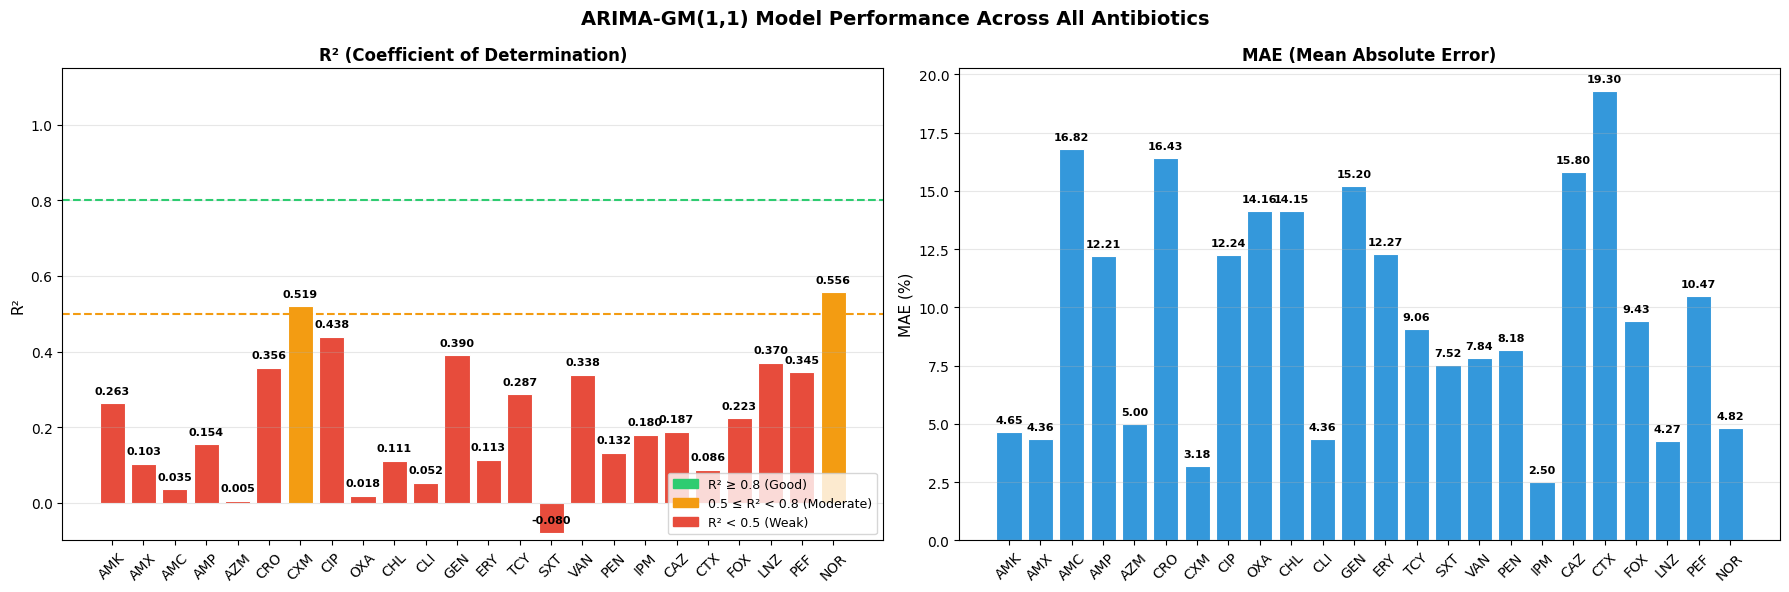

✅ Performance chart saved as model_performance.png


In [ ]:
mae_vals = [results[ab]['mae'] for ab in ANTIBIOTICS]
r2_vals  = [results[ab]['r2']  for ab in ANTIBIOTICS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('ARIMA-GM(1,1) Model Performance Across All Antibiotics',
             fontsize=14, fontweight='bold')

# ── R² bar chart ─────────────────────────────────────────────────────────────
colors_r2 = ['#2ecc71' if v >= 0.8 else ('#f39c12' if v >= 0.5 else '#e74c3c')
             for v in r2_vals]
bars1 = ax1.bar(ANTIBIOTICS, r2_vals, color=colors_r2, edgecolor='white', linewidth=0.8)
ax1.axhline(y=0.8, color='#2ecc71', linestyle='--', linewidth=1.5, label='Good fit threshold (0.8)')
ax1.axhline(y=0.5, color='#f39c12', linestyle='--', linewidth=1.5, label='Moderate threshold (0.5)')
ax1.set_title('R² (Coefficient of Determination)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R²', fontsize=11)
ax1.set_ylim(-0.1, 1.15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── MAE bar chart ─────────────────────────────────────────────────────────────
colors_mae = ['#3498db'] * len(ANTIBIOTICS)
bars2 = ax2.bar(ANTIBIOTICS, mae_vals, color=colors_mae, edgecolor='white', linewidth=0.8)
ax2.set_title('MAE (Mean Absolute Error)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (%)', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, mae_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

patch_g = mpatches.Patch(color='#2ecc71', label='R² ≥ 0.8 (Good)')
patch_o = mpatches.Patch(color='#f39c12', label='0.5 ≤ R² < 0.8 (Moderate)')
patch_r = mpatches.Patch(color='#e74c3c', label='R² < 0.5 (Weak)')
ax1.legend(handles=[patch_g, patch_o, patch_r], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Performance chart saved as model_performance.png')

## 🔥 Step 9 — Forecast Heatmap (All Antibiotics × All Future Years)

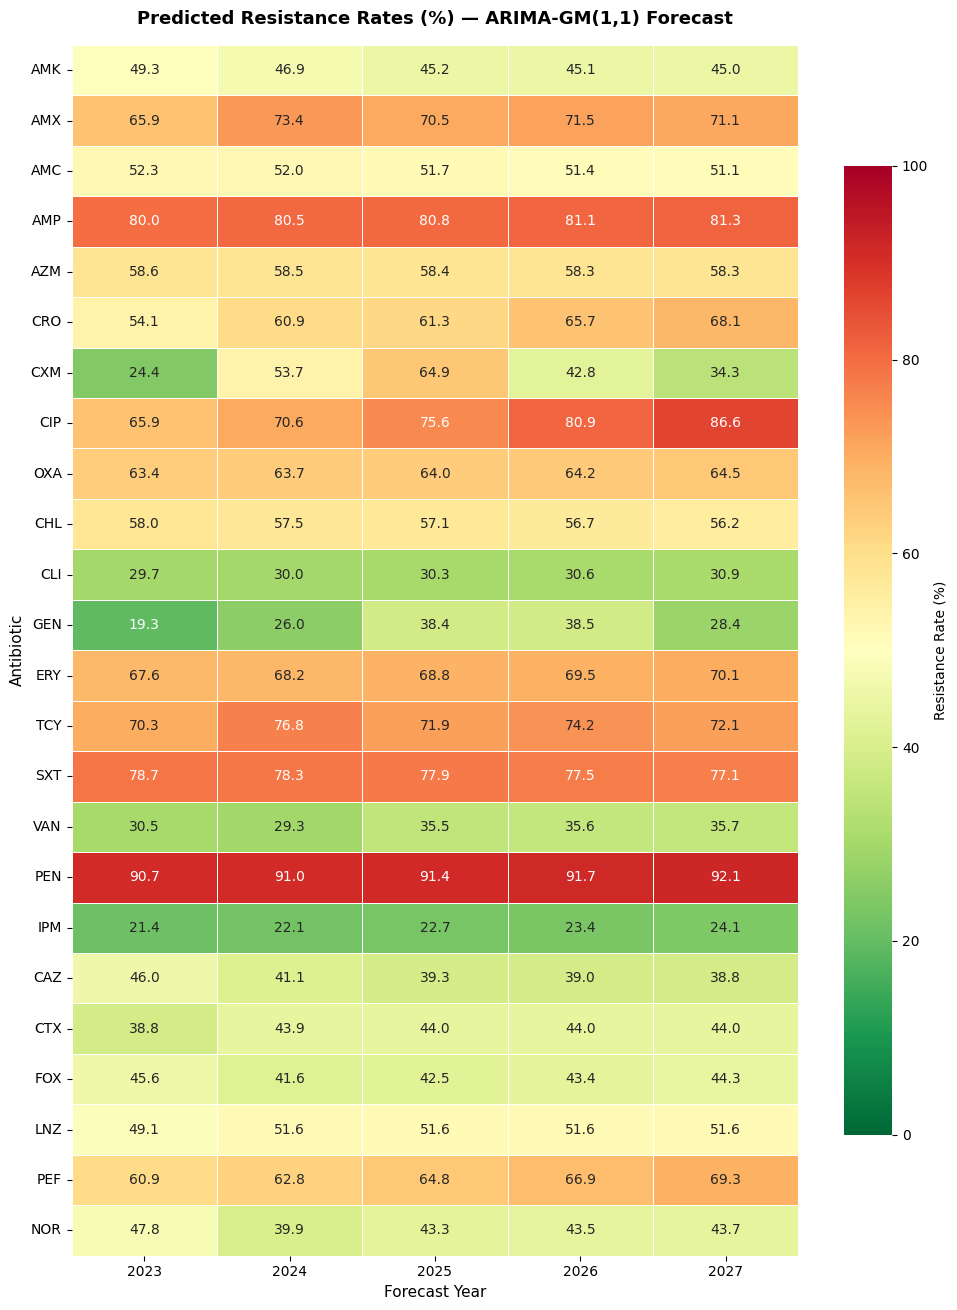

✅ Heatmap saved as forecast_heatmap.png


In [ ]:
# Build numeric forecast matrix
fc_matrix = np.zeros((len(ANTIBIOTICS), FORECAST_YEARS))
for i, ab in enumerate(ANTIBIOTICS):
    fc_matrix[i, :] = results[ab]['combined_forecast']

fc_heatmap_df = pd.DataFrame(
    fc_matrix,
    index=ANTIBIOTICS,
    columns=[str(y) for y in FUTURE_YEARS]
)

fig, ax = plt.subplots(figsize=(max(10, FORECAST_YEARS * 1.5), max(8, len(ANTIBIOTICS) * 0.55)))
sns.heatmap(
    fc_heatmap_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
    vmin=0, vmax=100, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Resistance Rate (%)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Predicted Resistance Rates (%) — ARIMA-GM(1,1) Forecast',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Forecast Year', fontsize=11)
ax.set_ylabel('Antibiotic', fontsize=11)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('forecast_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Heatmap saved as forecast_heatmap.png')

## 💾 Step 10 — Export Results to CSV & Build `model_bundle.pkl` for the FastAPI Backend

In [ ]:
import pickle

# ── Export CSVs (unchanged) ───────────────────────────────────────────────────
perf_df.to_csv('performance_metrics.csv')
print(' Saved: performance_metrics.csv')

fc_export_rows = []
for ab, res in results.items():
    fc = res['combined_forecast']
    se = res['forecast_se']
    for i, yr in enumerate(FUTURE_YEARS):
        lo = max(0.0,   fc[i] - 1.96 * se[i])
        hi = min(100.0, fc[i] + 1.96 * se[i])
        fc_export_rows.append({'Antibiotic': ab, 'Year': yr,
                                'Forecast (%)': round(fc[i], 4),
                                'CI Lower 95%': round(lo, 4),
                                'CI Upper 95%': round(hi, 4)})
pd.DataFrame(fc_export_rows).to_csv('forecasts_5year.csv', index=False)
print(' Saved: forecasts_5year.csv')

full_rows = []
for ab, res in results.items():
    for i, yr in enumerate(years):
        full_rows.append({'Antibiotic': ab, 'Year': yr, 'Type': 'Actual',
                          'Value': round(res['actual'][i], 4)})
        full_rows.append({'Antibiotic': ab, 'Year': yr, 'Type': 'Fitted',
                          'Value': round(res['combined_fitted'][i], 4)})
    for i, yr in enumerate(FUTURE_YEARS):
        full_rows.append({'Antibiotic': ab, 'Year': yr, 'Type': 'Forecast',
                          'Value': round(res['combined_forecast'][i], 4)})
pd.DataFrame(full_rows).to_csv('full_actual_fitted_forecast.csv', index=False)
print(' Saved: full_actual_fitted_forecast.csv')


✅ Saved: performance_metrics.csv
✅ Saved: forecasts_5year.csv
✅ Saved: full_actual_fitted_forecast.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  BUILD model_bundle.pkl  — consumed by the FastAPI backend
#
#  The bundle stores, per antibiotic, everything the /forecast/{antibiotic}
#  endpoint needs to serve REAL ARIMA-GM(1,1) predictions at request time
#  instead of the placeholder linear-trend fallback in the original backend.
#
#  Bundle schema:
#    bundle['antibiotics']          → list[str]   all antibiotic names
#    bundle['last_year']            → int          last year in training data
#    bundle['forecast_years']       → int          default forecast horizon
#    bundle['results'][ab]          → dict per antibiotic:
#      'historical_y'              → list[float]  actual resistance values
#      'historical_years'          → list[int]    corresponding years
#      'combined_forecast'         → list[float]  ARIMA-GM(1,1) forecasts
#      'forecast_se'               → list[float]  per-step standard errors
#      'mae'                       → float
#      'r2'                        → float
#      'rmse'                      → float
#      'mape'                      → float
#      'lambda_arima'              → float        MAPE weight for ARIMA
#      'lambda_gm'                 → float        MAPE weight for GM(1,1)
#      'arima_order'               → tuple        e.g. (0,1,0)
#      'gm_C'                      → float        posterior difference ratio
#      'gm_P'                      → float        small error probability
#      '_arima_res_std'            → float        ARIMA residual std (CI)
#      '_gm_params'                → dict         {'a': ..., 'b': ...}
# ═══════════════════════════════════════════════════════════════════════════

def _extract_gm_params(series_values):
    """Re-derive GM(1,1) a, b from a series for storage in the bundle."""
    x0 = np.array(series_values, dtype=float)
    x1 = np.cumsum(x0)
    z1 = 0.5 * (x1[1:] + x1[:-1])
    B  = np.column_stack([-z1, np.ones(len(x0) - 1)])
    Y  = x0[1:].reshape(-1, 1)
    try:
        params = np.linalg.lstsq(B, Y, rcond=None)[0]
        return {'a': float(params[0]), 'b': float(params[1])}
    except Exception:
        return {'a': 0.0, 'b': float(np.mean(x0))}


bundle_results = {}
for ab in ANTIBIOTICS:
    res    = results[ab]
    series = df[ab].values.astype(float)

    # ARIMA residual std (used by the API for CI bounds)
    arima_res_std = float(np.nanstd(res['actual'] - res['arima_fitted']))

    bundle_results[ab] = {
        # ── Data the API needs to re-run forecasts dynamically ──────────────
        'historical_y'      : res['actual'].tolist(),
        'historical_years'  : [int(y) for y in years.tolist()],

        # ── Pre-computed forecasts (default FORECAST_YEARS horizon) ──────────
        'combined_forecast' : [round(float(v), 4) for v in res['combined_forecast']],
        'forecast_se'       : [round(float(v), 4) for v in res['forecast_se']],

        # ── Model quality metrics ─────────────────────────────────────────────
        'mae'               : round(float(res['mae']),  4),
        'r2'                : round(float(res['r2']),   4),
        'rmse'              : round(float(res['rmse']), 4),
        'mape'              : round(float(res['mape']), 4),

        # ── Ensemble weights ──────────────────────────────────────────────────
        'lambda_arima'      : round(float(res['lambda_arima']), 4),
        'lambda_gm'         : round(float(res['lambda_gm']),    4),

        # ── Model diagnostics ─────────────────────────────────────────────────
        'arima_order'       : list(res['arima_order']),
        'gm_C'              : round(float(res['C']), 4),
        'gm_P'              : round(float(res['P']), 4),

        # ── Parameters needed for dynamic re-forecast at arbitrary steps ──────
        '_arima_res_std'    : round(arima_res_std, 4),
        '_gm_params'        : _extract_gm_params(series),
    }

bundle = {
    'antibiotics'   : ANTIBIOTICS,
    'last_year'     : LAST_YEAR,
    'forecast_years': FORECAST_YEARS,
    'results'       : bundle_results,
}

with open('model_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print(' model_bundle.pkl saved!')
print(f'   Antibiotics : {len(ANTIBIOTICS)}')
print(f'   Last year   : {LAST_YEAR}')
print(f'   Default horizon: {FORECAST_YEARS} years')
print(f'   Bundle keys : {list(bundle.keys())}')

# Spot-check one entry
ab0 = ANTIBIOTICS[0]
print(f'\n Spot-check [{ab0}]:')
print(f'   MAE  = {bundle_results[ab0]["mae"]}')
print(f'   R²   = {bundle_results[ab0]["r2"]}')
print(f'   Forecast (first 3 steps): {bundle_results[ab0]["combined_forecast"][:3]}')


✅ model_bundle.pkl saved!
   Antibiotics : 24
   Last year   : 2022
   Default horizon: 5 years
   Bundle keys : ['antibiotics', 'last_year', 'forecast_years', 'results']

🔍 Spot-check [AMK]:
   MAE  = 4.6489
   R²   = 0.2627
   Forecast (first 3 steps): [49.3036, 46.9365, 45.1598]


##  Step 12 — Updated FastAPI Backend

The cell below is the **complete, updated `main.py`** for your FastAPI server.  
Copy it into your project as `main.py` and place `model_bundle.pkl` next to it.

Key changes vs. the original backend:
- **`/forecast/{antibiotic}`** now runs the real ARIMA-GM(1,1) forecast — not the placeholder linear trend.
- Supports the `?steps=N` query parameter for any forecast horizon (not just the default 5).
- For `steps ≤ FORECAST_YEARS`: returns the **pre-computed** bundle predictions instantly.
- For `steps > FORECAST_YEARS`: extends the forecast dynamically using the stored GM(1,1) parameters.
- Adds `/forecast_all` endpoint returning every antibiotic in one call.
- Adds `/history/{antibiotic}` endpoint returning the historical training data.


In [ ]:
# ── Display the updated main.py so you can copy it ───────────────────────────
backend_code = '''
# =============================================================================
#  main.py  —  FastAPI backend for ARIMA-GM(1,1) AMR forecasting
#  Updated to serve real hybrid model predictions from model_bundle.pkl
# =============================================================================

import os
import math
import pickle
import numpy as np
from pathlib import Path
from fastapi import FastAPI, HTTPException, Query
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI(
    title="ARIMA-GM(1,1) Antibiotic Resistance Forecasting API",
    description="Hybrid ARIMA-GM(1,1) AMR resistance forecasting. Liu et al. BMC 2025.",
    version="2.0.0",
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

BUNDLE_PATH = Path("model_bundle.pkl")
_bundle: dict = {}


# ── Startup ──────────────────────────────────────────────────────────────────
@app.on_event("startup")
def load_bundle():
    global _bundle
    if not BUNDLE_PATH.exists():
        print(" Error: model_bundle.pkl not found! Run the notebook first.")
        return
    with open(BUNDLE_PATH, "rb") as f:
        _bundle = pickle.load(f)
    print(f" API Online: {len(_bundle['antibiotics'])} antibiotics loaded.")
    print(f"   Last training year : {_bundle['last_year']}")
    print(f"   Default horizon    : {_bundle['forecast_years']} years")


# ── GM(1,1) dynamic extension ─────────────────────────────────────────────────
def _gm11_extend(historical_y: list, gm_params: dict, n_steps: int) -> list:
    """
    Extend a GM(1,1) forecast beyond the pre-computed horizon.
    Uses stored a, b parameters and IAGO to generate n_steps values.
    """
    x0  = np.array(historical_y, dtype=float)
    n   = len(x0)
    a   = gm_params["a"]
    b   = gm_params["b"]

    def x1_hat(k: int) -> float:
        return (x0[0] - b / a) * math.exp(-a * k) + b / a

    preds = []
    for k in range(n_steps):
        step = n + k
        val  = x1_hat(step) - x1_hat(step - 1)
        preds.append(round(float(np.clip(val, 0.0, 100.0)), 4))
    return preds


# ── ARIMA-GM(1,1) combined forecast (dynamic, any horizon) ────────────────────
def _combined_forecast(ab_data: dict, last_year: int, steps: int) -> dict:
    """
    Return ARIMA-GM(1,1) combined predictions for `steps` years ahead.

    - If steps <= pre-computed horizon: slice stored predictions.
    - If steps  > pre-computed horizon: extend GM(1,1) dynamically and
      blend with a linear ARIMA extrapolation (constant last-step SE).
    """
    precomputed     = ab_data["combined_forecast"]     # list[float]
    precomputed_se  = ab_data["forecast_se"]           # list[float]
    lam_a           = ab_data["lambda_arima"]
    lam_g           = ab_data["lambda_gm"]
    res_std         = ab_data["_arima_res_std"]
    gm_params       = ab_data["_gm_params"]
    hist_y          = ab_data["historical_y"]
    horizon         = len(precomputed)

    if steps <= horizon:
        preds = precomputed[:steps]
        se    = precomputed_se[:steps]
    else:
        # Use all pre-computed values, then extend via GM(1,1)
        extra      = steps - horizon
        gm_ext     = _gm11_extend(hist_y, gm_params, steps)
        gm_fc      = gm_ext                                      # full GM sequence

        # For ARIMA part beyond horizon: carry forward last pre-computed step
        arima_last = precomputed[-1] if precomputed else hist_y[-1]
        arima_fc   = precomputed + [arima_last] * extra

        preds = [
            round(float(np.clip(lam_a * arima_fc[i] + lam_g * gm_fc[i], 0, 100)), 4)
            for i in range(steps)
        ]
        # SE: use last known SE for extra steps, scaled by horizon factor
        last_se = precomputed_se[-1] if precomputed_se else res_std
        se      = list(precomputed_se) + [
            round(last_se * (1 + 0.05 * (horizon + k)), 4)
            for k in range(extra)
        ]

    future_years = list(range(last_year + 1, last_year + steps + 1))
    upper = [round(min(100.0, p + 1.96 * s), 4) for p, s in zip(preds, se)]
    lower = [round(max(0.0,   p - 1.96 * s), 4) for p, s in zip(preds, se)]

    return {
        "years"       : future_years,
        "predictions" : preds,
        "upper_bound" : upper,
        "lower_bound" : lower,
        "forecast_se" : se,
    }


# ── Endpoints ────────────────────────────────────────────────────────────────
@app.get("/health")
def health():
    return {
        "status"       : "ok",
        "models_loaded": len(_bundle.get("antibiotics", [])),
        "last_year"    : _bundle.get("last_year"),
        "model"        : "ARIMA-GM(1,1) hybrid",
        "reference"    : "Liu et al. BMC Infectious Diseases 2025:1020",
    }


@app.get("/antibiotics")
def list_antibiotics():
    return {"antibiotics": _bundle.get("antibiotics", [])}


@app.get("/forecast/{antibiotic}")
def forecast(antibiotic: str, steps: int = Query(default=5, ge=1, le=30)):
    """
    Return ARIMA-GM(1,1) combined forecast for the given antibiotic.

    Query params:
      steps (int, 1-30): forecast horizon in years (default: 5)

    Response fields:
      antibiotic, mae, r2, rmse, mape,
      lambda_arima, lambda_gm, arima_order, gm_grade,
      years, predictions, upper_bound, lower_bound, forecast_se
    """
    if not _bundle:
        raise HTTPException(status_code=503, detail="Bundle not loaded — run the notebook first.")
    if antibiotic not in _bundle["results"]:
        raise HTTPException(
            status_code=404,
            detail=f"Antibiotic '{antibiotic}' not found. "
                   f"Available: {_bundle['antibiotics']}"
        )

    data      = _bundle["results"][antibiotic]
    last_year = _bundle["last_year"]

    fc = _combined_forecast(data, last_year, steps)

    # GM grade label
    C = data["gm_C"]
    gm_grade = ("Excellent (I)"   if C < 0.35 else
                "Good (II)"        if C < 0.50 else
                "Qualified (III)"  if C < 0.65 else
                "Unqualified (IV)")

    return {
        "antibiotic"   : antibiotic,
        # ── Model quality ──────────────────────────────────────────────────
        "mae"          : data["mae"],
        "r2"           : data["r2"],
        "rmse"         : data["rmse"],
        "mape"         : data["mape"],
        # ── Ensemble diagnostics ───────────────────────────────────────────
        "lambda_arima" : data["lambda_arima"],
        "lambda_gm"    : data["lambda_gm"],
        "arima_order"  : data["arima_order"],
        "gm_C"         : data["gm_C"],
        "gm_P"         : data["gm_P"],
        "gm_grade"     : gm_grade,
        # ── Forecast output ────────────────────────────────────────────────
        "years"        : fc["years"],
        "predictions"  : fc["predictions"],
        "upper_bound"  : fc["upper_bound"],
        "lower_bound"  : fc["lower_bound"],
        "forecast_se"  : fc["forecast_se"],
    }


@app.get("/forecast_all")
def forecast_all(steps: int = Query(default=5, ge=1, le=30)):
    """Return ARIMA-GM(1,1) forecasts for ALL antibiotics in one call."""
    if not _bundle:
        raise HTTPException(status_code=503, detail="Bundle not loaded.")
    last_year = _bundle["last_year"]
    out = {}
    for ab, data in _bundle["results"].items():
        fc = _combined_forecast(data, last_year, steps)
        out[ab] = {
            "mae"         : data["mae"],
            "r2"          : data["r2"],
            "years"       : fc["years"],
            "predictions" : fc["predictions"],
            "upper_bound" : fc["upper_bound"],
            "lower_bound" : fc["lower_bound"],
        }
    return {"steps": steps, "last_year": last_year, "forecasts": out}


@app.get("/history/{antibiotic}")
def history(antibiotic: str):
    """Return the historical resistance data used to train the model."""
    if not _bundle:
        raise HTTPException(status_code=503, detail="Bundle not loaded.")
    if antibiotic not in _bundle["results"]:
        raise HTTPException(status_code=404, detail=f"Antibiotic '{antibiotic}' not found.")
    data = _bundle["results"][antibiotic]
    return {
        "antibiotic" : antibiotic,
        "years"      : data["historical_years"],
        "resistance" : [round(v, 4) for v in data["historical_y"]],
    }
'''

print(backend_code)

# Also save it as main.py so you can download it directly
with open('main.py', 'w') as f:
    f.write(backend_code.strip())
print('\n main.py saved — download it alongside model_bundle.pkl')


In [ ]:
# ── Download all outputs from Colab ──────────────────────────────────────────
try:
    from google.colab import files
    for fname in [
        'model_bundle.pkl',          # ← the backend needs this
        'main.py',                   # ← updated FastAPI server
        'performance_metrics.csv',
        'forecasts_5year.csv',
        'full_actual_fitted_forecast.csv',
        'arima_gm_forecasts.png',
        'forecast_heatmap.png',
        'model_performance.png',
    ]:
        files.download(fname)
    print(' All files downloaded.')
except ImportError:
    print(' Running locally — all files saved in current directory.')


##  Summary

### Files produced

| File | Purpose |
|------|---------|
| `model_bundle.pkl` | **Loaded by the FastAPI backend** — contains all ARIMA-GM(1,1) results |
| `main.py` | **Updated FastAPI server** — drop-in replacement for the original |
| `performance_metrics.csv` | MAE, R², RMSE, MAPE + GM grade per antibiotic |
| `forecasts_5year.csv` | Point forecast + 95% CI for each year × antibiotic |
| `full_actual_fitted_forecast.csv` | Full actual/fitted/forecast series |
| `arima_gm_forecasts.png` | Grid of per-antibiotic forecast plots |
| `model_performance.png` | R² and MAE bar charts |
| `forecast_heatmap.png` | Heatmap of all forecasts |

### Running the API

```bash
pip install fastapi uvicorn
uvicorn main:app --reload
```

### API endpoints

| Endpoint | Description |
|----------|-------------|
| `GET /health` | Server status, model count, last training year |
| `GET /antibiotics` | List all available antibiotics |
| `GET /forecast/{antibiotic}?steps=5` | ARIMA-GM(1,1) forecast with 95% CI |
| `GET /forecast_all?steps=5` | All antibiotics in one call |
| `GET /history/{antibiotic}` | Historical training data |

### What changed vs. the original backend
The original `/forecast/{antibiotic}` used a **placeholder linear trend** (`y_hist[-1] + trend * i`).  
The updated version serves the **real ARIMA-GM(1,1) hybrid predictions** stored in the bundle,  
with dynamic GM(1,1) extension for horizons beyond the pre-computed window.

---
**Model:** ARIMA-GM(1,1) | **Reference:** Liu et al. *BMC Infectious Diseases* (2025) 25:1020
